In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_ebay_deals.csv")


Matplotlib is building the font cache; this may take a moment.


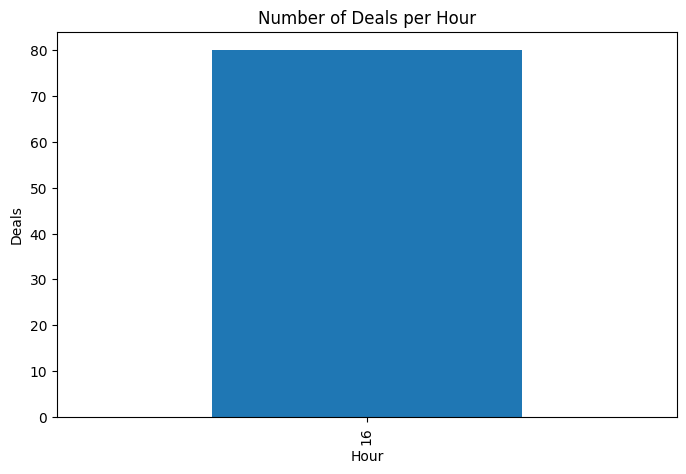

In [3]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

df["hour"] = df["timestamp"].dt.hour

hour_counts = df.groupby("hour").size()

plt.figure(figsize=(8,5))
hour_counts.plot(kind="bar")
plt.title("Number of Deals per Hour")
plt.xlabel("Hour")
plt.ylabel("Deals")
plt.show()

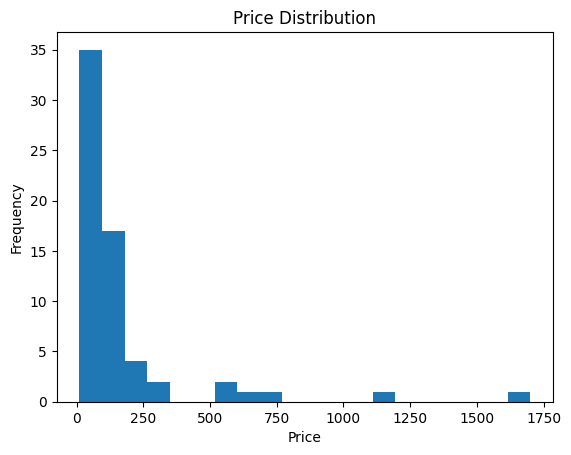

In [4]:
plt.hist(df["price"].dropna(), bins=20)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

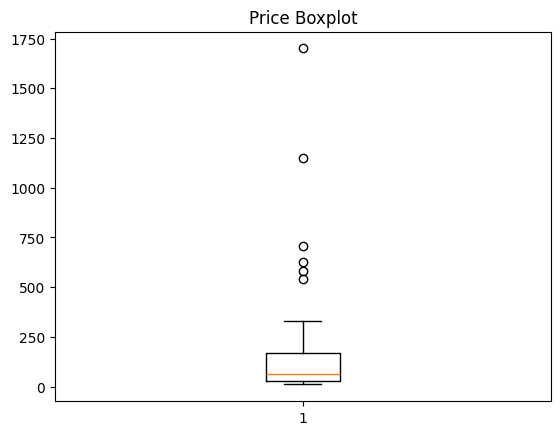

In [6]:
plt.boxplot(df["price"].dropna())
plt.title("Price Boxplot")
plt.show()

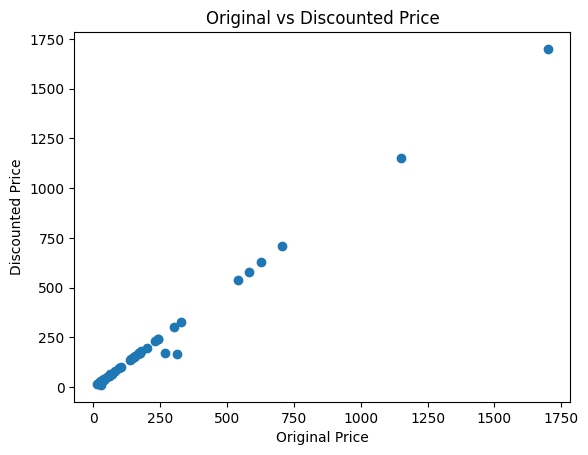

In [7]:
plt.scatter(df["original_price"], df["price"])
plt.xlabel("Original Price")
plt.ylabel("Discounted Price")
plt.title("Original vs Discounted Price")
plt.show()

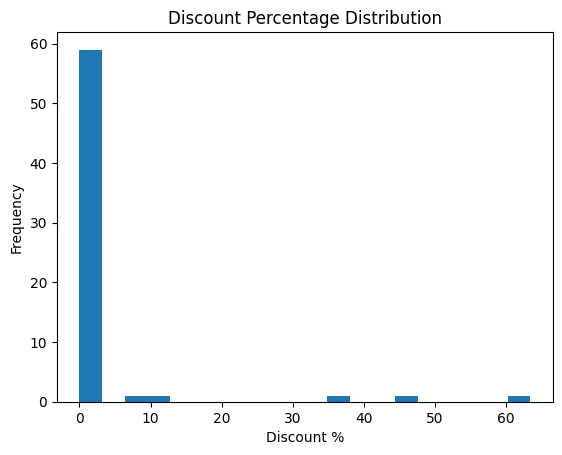

In [8]:
plt.hist(df["discount_percentage"].dropna(), bins=20)
plt.title("Discount Percentage Distribution")
plt.xlabel("Discount %")
plt.ylabel("Frequency")
plt.show()

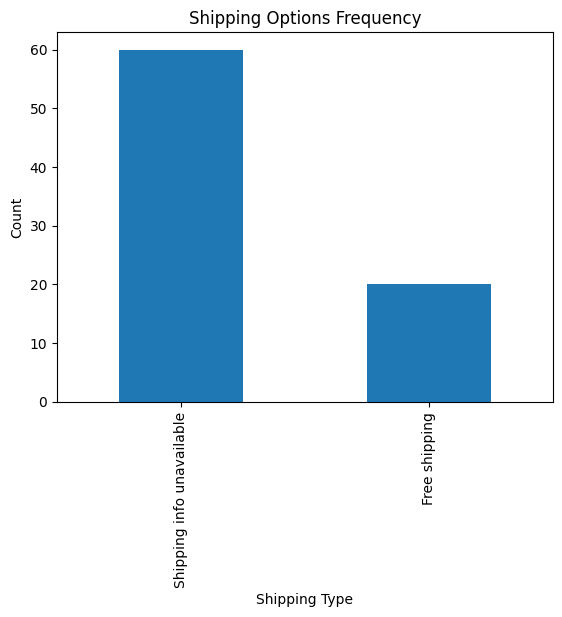

In [9]:
shipping_counts = df["shipping"].value_counts()

shipping_counts.plot(kind="bar")
plt.title("Shipping Options Frequency")
plt.xlabel("Shipping Type")
plt.ylabel("Count")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_16088\144413055.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=keyword_df.index, y=keyword_df.values, palette="viridis")


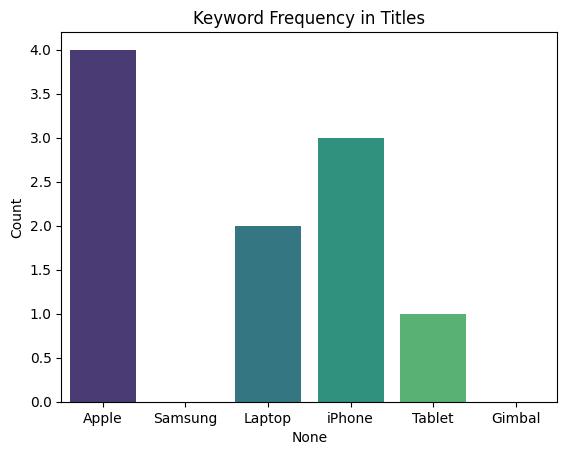

In [10]:
keywords = ["Apple","Samsung","Laptop","iPhone","Tablet","Gimbal"]

counts = {}

for word in keywords:
    counts[word] = df["title"].str.contains(word, case=False, na=False).sum()

keyword_df = pd.Series(counts)

sns.barplot(x=keyword_df.index, y=keyword_df.values, palette="viridis")
plt.title("Keyword Frequency in Titles")
plt.ylabel("Count")
plt.show()

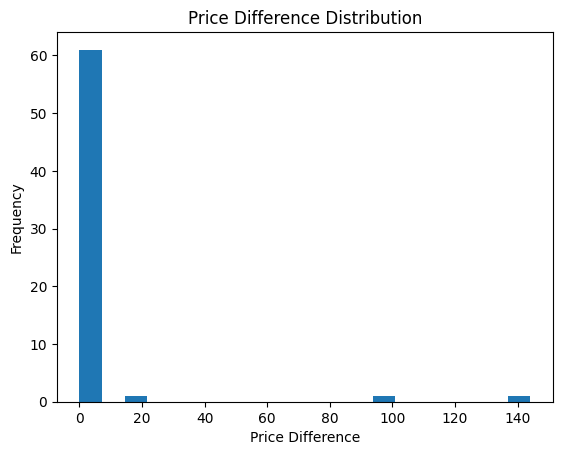

In [11]:
df["price_difference"] = df["original_price"] - df["price"]

plt.hist(df["price_difference"].dropna(), bins=20)
plt.title("Price Difference Distribution")
plt.xlabel("Price Difference")
plt.ylabel("Frequency")
plt.show()

In [12]:
df.sort_values("discount_percentage", ascending=False).head(5)

,timestamp,title,price,original_price,shipping,item_url,discount_percentage,hour,price_difference
61,2026-10-03 16:03:00,Married With Children ~ Complete 5th Fifth Sea...,10.95,29.95,Free shipping,https://www.ebay.com/itm/406697763087?_trkparm...,63.44,16,19.00
53,2026-10-03 16:03:00,CANON RF-S10-18mm F4.5-6.3 IS STM Ultra Wide Z...,167.20,311.25,Shipping info unavailable,https://www.ebay.com/itm/187782830629?_trkparm...,46.28,16,144.05
33,2026-10-03 16:03:00,"12"" Streaming Rear Camera Mirror with GPS Wifi...",169.47,269.00,Free shipping,https://www.ebay.com/itm/277333610887?_trkparm...,37.00,16,99.53
17,2026-10-03 16:03:00,New Genuine MR22GA AKB76039907 For LG Magic Bl...,25.83,28.70,Free shipping,https://www.ebay.com/itm/127224348199?_trkparm...,10.00,16,2.87
1,2026-10-03 16:03:00,Nokia 1209 - Midnight Blue (Unlocked) Cellular...,36.97,40.18,Free shipping,https://www.ebay.com/itm/167612398310?_trkparm...,7.99,16,3.21
